# AutoFitter Tutorial

This notebook demonstrates how to use the `AutoFitter` class for automatic distribution selection and comparison.

## Overview

`AutoFitter` is designed to:
- Automatically test multiple probability distributions
- Select the best-fitting distribution based on various criteria (RMSE, AIC, BIC, etc.)
- Support all 113 SciPy continuous distributions
- Use lazy initialization for memory efficiency
- Provide comprehensive comparison tables and rankings

## ⭐ Best Practice: Use RMSE for Distribution Selection

**For real-world data, we strongly recommend using RMSE (Root Mean Square Error) as the primary criterion** for selecting the best distribution. Here's why:

- **RMSE is robust**: Directly measures fit quality without being affected by sample size
- **Avoids p-value inflation**: P-values from goodness-of-fit tests (KS, Chi-square) can become unreliable with large datasets due to the "large sample size effect" (see MagicAdjuster tutorial for details)
- **Practical significance**: RMSE reflects actual fit quality, not just statistical significance

In this tutorial, we use **synthetic data** where p-values are more reliable. However, keep in mind that real-world data often exhibits the large sample size effect, making RMSE the safer choice.

## Setup and Data Generation

Let's create some sample data that follows a known distribution to test AutoFitter's capability.

Generated 1000 wind speed measurements
Min: 0.69 m/s
Max: 27.57 m/s
Mean: 7.04 m/s
Std: 3.70 m/s


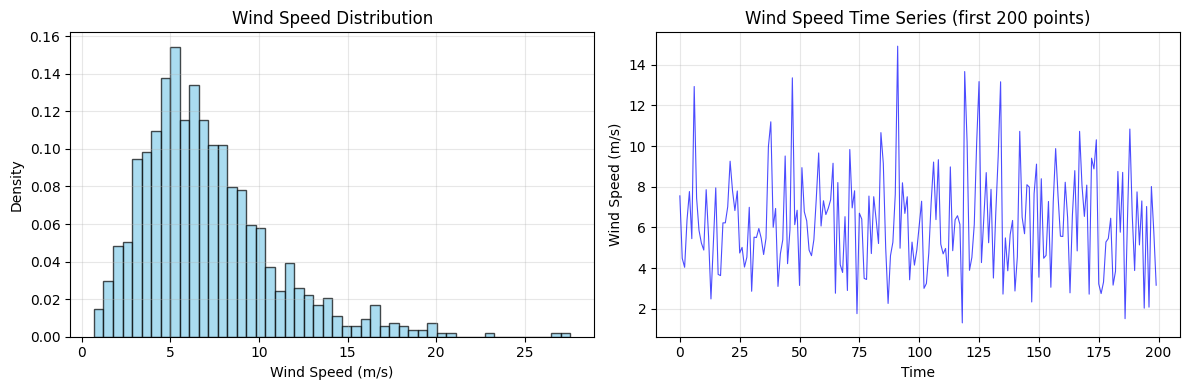

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import magica as ma
from magica.core.auto_fitter import AutoFitter

# Set random seed for reproducibility
np.random.seed(123)

# Generate mixed wind speed data (complex scenario)
# Simulate different weather conditions
low_wind = np.random.weibull(2, 400) * 6 + 1    # Calm periods
normal_wind = np.random.lognormal(2, 0.5, 400)  # Variable periods  
high_wind = np.random.gamma(3, 2, 200)          # Storm periods

# Combine all periods
wind_data = np.concatenate([low_wind, normal_wind, high_wind])

print(f"Generated {len(wind_data)} wind speed measurements")
print(f"Min: {wind_data.min():.2f} m/s")
print(f"Max: {wind_data.max():.2f} m/s")
print(f"Mean: {wind_data.mean():.2f} m/s")
print(f"Std: {wind_data.std():.2f} m/s")

# Visualize the data
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(wind_data, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Density')
plt.title('Wind Speed Distribution')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(wind_data[:200], 'b-', alpha=0.7, linewidth=0.8)
plt.xlabel('Time')
plt.ylabel('Wind Speed (m/s)')
plt.title('Wind Speed Time Series (first 200 points)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Basic AutoFitter Usage

Let's start with the default configuration that tests a curated set of stable distributions.

In [2]:
# Load data into MagicA
processor = ma.read_data(wind_data)
print(f"Loaded data: {processor}")

# Create AutoFitter with default settings
auto_fitter = processor.get_auto_fitter(criterion='rmse')
print(f"\nCreated AutoFitter: {auto_fitter}")
print(f"Default candidates ({len(auto_fitter.candidates)}): {auto_fitter.candidates}")

Loaded data: DataProcessor(length=1000, dtype=float64)

Created AutoFitter: AutoFitter(candidates=16, criterion=rmse, not fitted)
Default candidates (16): ['weibull_min', 'lognorm', 'gamma', 'norm', 'expon', 'rayleigh', 'chi2', 'beta', 'uniform', 'logistic', 'gumbel_r', 'pareto', 'invgamma', 'maxwell', 'triang', 'laplace']


In [3]:
# Find the best distribution automatically
print("Finding best distribution from default candidates...")
best_result = auto_fitter.fit_best_distribution()

print(f"\n🏆 Best Distribution: {best_result['distribution']}")
print(f"📊 RMSE: {best_result['rmse']:.6f}")
print(f"📈 AIC: {best_result['aic']:.2f}")
print(f"📉 BIC: {best_result['bic']:.2f}")
print(f"🔍 KS p-value: {best_result['ks_pvalue']:.6f}")
print(f"⚙️ Parameters: {best_result['parameters']}")

Finding best distribution from default candidates...
Testing 16 distributions...
  [1/16] Fitting weibull_min...
  [2/16] Fitting lognorm...
  [3/16] Fitting gamma...
  [4/16] Fitting norm...
  [5/16] Fitting expon...
  [6/16] Fitting rayleigh...
  [7/16] Fitting chi2...
  [8/16] Fitting beta...
  [9/16] Fitting uniform...
  [10/16] Fitting logistic...
  [11/16] Fitting gumbel_r...
  [12/16] Fitting pareto...
  [13/16] Fitting invgamma...
  [14/16] Fitting maxwell...
  [15/16] Fitting triang...
  [16/16] Fitting laplace...
✓ All distributions fitted successfully

🏆 Best Distribution: invgamma
📊 RMSE: 0.005408
📈 AIC: 5223.26
📉 BIC: 5237.99
🔍 KS p-value: 0.987903
⚙️ Parameters: (np.float64(11.904082560566334), np.float64(-4.656117427894967), np.float64(127.54022278354164))
  [16/16] Fitting laplace...
✓ All distributions fitted successfully

🏆 Best Distribution: invgamma
📊 RMSE: 0.005408
📈 AIC: 5223.26
📉 BIC: 5237.99
🔍 KS p-value: 0.987903
⚙️ Parameters: (np.float64(11.904082560566334), 

/Users/danilocoutodesouza/miniconda3/envs/magica/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:796: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/Users/danilocoutodesouza/miniconda3/envs/magica/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:801: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))


## Comprehensive Distribution Comparison

Let's look at how all tested distributions performed.

In [4]:
# Get comprehensive comparison table
comparison = auto_fitter.get_comparison_table(sort_by='rmse')

print("📊 Distribution Ranking (by RMSE):")
print("=" * 90)
print(f"{'Rank':<4} {'Distribution':<15} {'RMSE':<12} {'AIC':<10} {'KS p-value':<12} {'Status'}")
print("=" * 90)

successful_results = [(dist, result) for dist, result in comparison.items() if result['success']]
failed_results = [(dist, result) for dist, result in comparison.items() if not result['success']]

# For synthetic data, we can also filter by p-value > 0.05 (good statistical fit)
# Note: For real-world data, this filtering may be too strict due to large sample size effect
good_fit_results = [(dist, result) for dist, result in successful_results if result['ks_pvalue'] > 0.05]

print("🎯 Top 10 Distributions (with KS p-value > 0.05):")
print("-" * 90)
for i, (dist, result) in enumerate(good_fit_results[:10], 1):
    print(f"{i:<4} {dist:<15} {result['rmse']:<12.6f} {result['aic']:<10.1f} {result['ks_pvalue']:<12.6f} ✅ Good")

if len(good_fit_results) < 10:
    print("\n⚠️  Showing remaining distributions (KS p-value < 0.05):")
    print("-" * 90)
    fair_fit_results = [(dist, result) for dist, result in successful_results if result['ks_pvalue'] <= 0.05]
    for i, (dist, result) in enumerate(fair_fit_results[:10-len(good_fit_results)], len(good_fit_results)+1):
        print(f"{i:<4} {dist:<15} {result['rmse']:<12.6f} {result['aic']:<10.1f} {result['ks_pvalue']:<12.6f} ⚠️ Fair")

print(f"\n📊 Summary:")
print(f"✅ Successful fits: {len(successful_results)}")
print(f"📈 Good statistical fit (p > 0.05): {len(good_fit_results)}")
print(f"⚠️  Fair fit (p ≤ 0.05): {len(successful_results) - len(good_fit_results)}")
print(f"❌ Failed fits: {len(failed_results)}")

print(f"\n💡 Note: In this synthetic data example, we can filter by p-value > 0.05.")
print(f"   However, for real-world data, p-values often become unreliable due to")
print(f"   the 'large sample size effect'. In such cases, use RMSE alone!")
if failed_results:
    print(f"\nFailed distributions: {[dist for dist, _ in failed_results]}")

📊 Distribution Ranking (by RMSE):
Rank Distribution    RMSE         AIC        KS p-value   Status
🎯 Top 10 Distributions (with KS p-value > 0.05):
------------------------------------------------------------------------------------------
1    invgamma        0.005408     5223.3     0.987903     ✅ Good
2    gumbel_r        0.005897     5224.6     0.980487     ✅ Good
3    lognorm         0.007012     5223.3     0.938914     ✅ Good
4    gamma           0.012079     5227.6     0.672461     ✅ Good
5    weibull_min     0.024757     5255.5     0.063202     ✅ Good

⚠️  Showing remaining distributions (KS p-value < 0.05):
------------------------------------------------------------------------------------------
6    beta            0.022798     5263.6     0.042823     ⚠️ Fair
7    logistic        0.027776     5379.4     0.005291     ⚠️ Fair
8    rayleigh        0.031457     5267.5     0.002930     ⚠️ Fair
9    laplace         0.032053     5397.8     0.000141     ⚠️ Fair
10   maxwell         0.

## Using the Best-Fitted Distribution

Once we have the best distribution, we can use it just like a regular MagicAdjuster.

In [5]:
# Get the adjuster for the best distribution
best_adjuster = auto_fitter.get_best_adjuster()
print(f"Best adjuster: {best_adjuster}")

# Use it like any MagicAdjuster - calculate key statistics
mean_wind = best_adjuster.stats(moments='m')
percentile_50 = best_adjuster.ppf(0.5)   # Median
percentile_95 = best_adjuster.ppf(0.95)  # 95th percentile
percentile_99 = best_adjuster.ppf(0.99)  # 99th percentile

print(f"\n📊 Wind Speed Statistics (from best-fitted {best_result['distribution']}):")
print(f"Mean: {mean_wind:.2f} m/s")
print(f"Median (50th percentile): {percentile_50:.2f} m/s")
print(f"95th percentile: {percentile_95:.2f} m/s")
print(f"99th percentile: {percentile_99:.2f} m/s")

# Calculate probabilities for specific thresholds
prob_exceed_15 = 1 - best_adjuster.cdf(15)  # P(wind > 15 m/s)
prob_below_5 = best_adjuster.cdf(5)          # P(wind ≤ 5 m/s)

print(f"\n⚡ Risk Assessment:")
print(f"Probability of exceeding 15 m/s: {prob_exceed_15:.4f} ({prob_exceed_15*100:.2f}%)")
print(f"Probability of calm conditions (≤ 5 m/s): {prob_below_5:.4f} ({prob_below_5*100:.2f}%)")

Best adjuster: MagicAdjuster(data_size=1000, distribution='invgamma')

📊 Wind Speed Statistics (from best-fitted invgamma):
Mean: 7.04 m/s
Median (50th percentile): 6.36 m/s
95th percentile: 13.96 m/s
99th percentile: 19.12 m/s

⚡ Risk Assessment:
Probability of exceeding 15 m/s: 0.0359 (3.59%)
Probability of calm conditions (≤ 5 m/s): 0.3224 (32.24%)


## Testing All Available Distributions

For the most comprehensive analysis, let's test ALL 113 available distributions!

In [6]:
# Get all available distributions
all_distributions = AutoFitter.get_all_available_distributions()
print(f"🌍 Total available distributions: {len(all_distributions)}")
print(f"First 20: {all_distributions[:20]}")
print(f"Last 20: {all_distributions[-20:]}")

# Create AutoFitter with ALL distributions
print("\n⚠️  Warning: Testing all distributions takes longer but is more comprehensive")
auto_fitter_comprehensive = processor.get_auto_fitter(
    candidates=all_distributions,  # Use ALL 113 distributions!
    criterion='rmse'  # ⭐ Use RMSE (most reliable criterion)
)

print(f"Created comprehensive AutoFitter: {auto_fitter_comprehensive}")

🌍 Total available distributions: 111
First 20: ['alpha', 'anglit', 'arcsine', 'argus', 'beta', 'betaprime', 'bradford', 'burr', 'burr12', 'cauchy', 'chi', 'chi2', 'cosine', 'crystalball', 'dgamma', 'dpareto_lognorm', 'dweibull', 'erlang', 'expon', 'exponnorm']
Last 20: ['skewcauchy', 'skewnorm', 'students_t', 't', 'trapezoid', 'trapz', 'triang', 'truncexpon', 'truncnorm', 'truncpareto', 'truncweibull_min', 'tukeylambda', 'uniform', 'vonmises', 'vonmises_line', 'wald', 'weibull', 'weibull_max', 'weibull_min', 'wrapcauchy']

⚠️  Warning: Testing all distributions takes longer but is more comprehensive
Created comprehensive AutoFitter: AutoFitter(candidates=111, criterion=rmse, not fitted)


In [7]:
# Find best from ALL distributions (this takes a moment...)
print("🔍 Testing ALL 113 distributions... (this may take 30-60 seconds)")
best_comprehensive = auto_fitter_comprehensive.fit_best_distribution()

print(f"\n🏆 Best Distribution (from ALL 113): {best_comprehensive['distribution']}")
print(f"📊 RMSE: {best_comprehensive['rmse']:.6f} ⭐ (Primary criterion)")
print(f"📈 AIC: {best_comprehensive['aic']:.2f}")
print(f"📉 BIC: {best_comprehensive['bic']:.2f}")
print(f"🔍 KS p-value: {best_comprehensive['ks_pvalue']:.6f}")

# Compare with default selection
print(f"\n🔬 Comparison:")
print(f"Default selection ({len(auto_fitter.candidates)} dists): {best_result['distribution']} (RMSE: {best_result['rmse']:.6f})")
print(f"Comprehensive ({len(all_distributions)} dists): {best_comprehensive['distribution']} (RMSE: {best_comprehensive['rmse']:.6f})")

improvement = ((best_result['rmse'] - best_comprehensive['rmse']) / best_result['rmse']) * 100
print(f"Improvement: {improvement:.2f}% reduction in RMSE")

🔍 Testing ALL 113 distributions... (this may take 30-60 seconds)
Testing 111 distributions...
  [1/111] Fitting alpha...
  [2/111] Fitting anglit...
  [3/111] Fitting arcsine...
  [4/111] Fitting argus...
  [5/111] Fitting beta...
  [5/111] Fitting beta...
  [6/111] Fitting betaprime...
  [6/111] Fitting betaprime...
  [7/111] Fitting bradford...
  [8/111] Fitting burr...
  [7/111] Fitting bradford...
  [8/111] Fitting burr...
  [9/111] Fitting burr12...
  [9/111] Fitting burr12...
  [10/111] Fitting cauchy...
  [11/111] Fitting chi...
  [12/111] Fitting chi2...
  [10/111] Fitting cauchy...
  [11/111] Fitting chi...
  [12/111] Fitting chi2...
  [13/111] Fitting cosine...
  [14/111] Fitting crystalball...
  [15/111] Fitting dgamma...
  [16/111] Fitting dpareto_lognorm...
  [13/111] Fitting cosine...
  [14/111] Fitting crystalball...
  [15/111] Fitting dgamma...
  [16/111] Fitting dpareto_lognorm...


/Users/danilocoutodesouza/miniconda3/envs/magica/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:1956: RuntimeWarning: divide by zero encountered in divide
  out = (a * b) / ((a - k) * (b + k)) * np.exp(k * m + k ** 2 * s ** 2 / 2)


  [17/111] Fitting dweibull...
  [18/111] Fitting erlang...
  [19/111] Fitting expon...
  [20/111] Fitting exponnorm...
  [21/111] Fitting exponpow...
  [22/111] Fitting exponweib...


/Users/danilocoutodesouza/miniconda3/envs/magica/lib/python3.11/site-packages/scipy/optimize/_optimize.py:560: RuntimeWarning: The shape parameter of the erlang distribution has been given a non-integer value np.float64(2.1).
  fx = function(np.copy(x), *(wrapper_args + args))
/Users/danilocoutodesouza/miniconda3/envs/magica/lib/python3.11/site-packages/scipy/optimize/_optimize.py:560: RuntimeWarning: The shape parameter of the erlang distribution has been given a non-integer value np.float64(2.0666666666666664).
  fx = function(np.copy(x), *(wrapper_args + args))
/Users/danilocoutodesouza/miniconda3/envs/magica/lib/python3.11/site-packages/scipy/optimize/_optimize.py:560: RuntimeWarning: The shape parameter of the erlang distribution has been given a non-integer value np.float64(2.0999999999999996).
  fx = function(np.copy(x), *(wrapper_args + args))
/Users/danilocoutodesouza/miniconda3/envs/magica/lib/python3.11/site-packages/scipy/optimize/_optimize.py:560: RuntimeWarning: The shape

  [23/111] Fitting f...
  [24/111] Fitting fatiguelife...
  [25/111] Fitting fisk...
  [26/111] Fitting foldcauchy...
  [27/111] Fitting foldnorm...
  [28/111] Fitting gamma...
  [29/111] Fitting gausshyper...
  [30/111] Fitting genexpon...
  [31/111] Fitting genextreme...
  [32/111] Fitting gengamma...
  [30/111] Fitting genexpon...
  [31/111] Fitting genextreme...
  [32/111] Fitting gengamma...
  [33/111] Fitting genhalflogistic...
  [34/111] Fitting genhyperbolic...
  [33/111] Fitting genhalflogistic...
  [34/111] Fitting genhyperbolic...
  [35/111] Fitting geninvgauss...
  [35/111] Fitting geninvgauss...
  [36/111] Fitting genlogistic...
  [37/111] Fitting gennorm...
  [38/111] Fitting genpareto...
  [39/111] Fitting gibrat...
  [40/111] Fitting gompertz...
  [41/111] Fitting gumbel_l...
  [42/111] Fitting gumbel_r...
  [43/111] Fitting halfcauchy...
  [44/111] Fitting halfgennorm...
  [36/111] Fitting genlogistic...
  [37/111] Fitting gennorm...
  [38/111] Fitting genpareto...
  [

/Users/danilocoutodesouza/Documents/Programs_and_scripts/MagicA/magica/core/auto_fitter.py:208: UserWarning: Failed to fit irwinhall: Failed to fit irwinhall distribution: The generic `fit` implementation is unreliable for this distribution, and no custom implementation is available. Consider using `scipy.stats.fit`.
  warnings.warn(f"Failed to fit {distribution}: {e}")


  [54/111] Fitting johnsonsu...
  [55/111] Fitting kappa3...
  [56/111] Fitting kappa4...
  [57/111] Fitting ksone...
  [58/111] Fitting kstwo...
  [59/111] Fitting kstwobign...
  [60/111] Fitting landau...
  [61/111] Fitting laplace...
  [62/111] Fitting laplace_asymmetric...
  [63/111] Fitting levy...
  [64/111] Fitting levy_l...
  [65/111] Fitting loggamma...
  [66/111] Fitting logistic...
  [67/111] Fitting loglaplace...
  [68/111] Fitting lognorm...
  [69/111] Fitting loguniform...
  [70/111] Fitting lomax...
  [57/111] Fitting ksone...
  [58/111] Fitting kstwo...
  [59/111] Fitting kstwobign...
  [60/111] Fitting landau...
  [61/111] Fitting laplace...
  [62/111] Fitting laplace_asymmetric...
  [63/111] Fitting levy...
  [64/111] Fitting levy_l...
  [65/111] Fitting loggamma...
  [66/111] Fitting logistic...
  [67/111] Fitting loglaplace...
  [68/111] Fitting lognorm...
  [69/111] Fitting loguniform...
  [70/111] Fitting lomax...


/Users/danilocoutodesouza/Documents/Programs_and_scripts/MagicA/magica/core/auto_fitter.py:208: UserWarning: Failed to fit kstwo: Failed to fit kstwo distribution: Iteration of zero-sized operands is not enabled
  warnings.warn(f"Failed to fit {distribution}: {e}")


  [71/111] Fitting maxwell...
  [72/111] Fitting mielke...
  [73/111] Fitting moyal...
  [74/111] Fitting nakagami...
  [75/111] Fitting ncf...
  [76/111] Fitting nct...
  [76/111] Fitting nct...
  [77/111] Fitting ncx2...
  [77/111] Fitting ncx2...
  [78/111] Fitting norm...
  [79/111] Fitting norminvgauss...
  [78/111] Fitting norm...
  [79/111] Fitting norminvgauss...
  [80/111] Fitting pareto...
  [81/111] Fitting pearson3...
  [82/111] Fitting powerlaw...
  [83/111] Fitting powerlognorm...
  [84/111] Fitting powernorm...
  [80/111] Fitting pareto...
  [81/111] Fitting pearson3...
  [82/111] Fitting powerlaw...
  [83/111] Fitting powerlognorm...
  [84/111] Fitting powernorm...
  [85/111] Fitting rayleigh...
  [86/111] Fitting rdist...
  [87/111] Fitting recipinvgauss...
  [85/111] Fitting rayleigh...
  [86/111] Fitting rdist...
  [87/111] Fitting recipinvgauss...
  [88/111] Fitting reciprocal...
  [89/111] Fitting rel_breitwigner...
  [90/111] Fitting rice...
  [91/111] Fitting sem

## Top Performers Analysis

Let's analyze the top-performing distributions from the comprehensive test.

In [8]:
# Get comprehensive comparison
comprehensive_comparison = auto_fitter_comprehensive.get_comparison_table(sort_by='rmse')  # ⭐ Sort by RMSE
successful_comprehensive = [(dist, result) for dist, result in comprehensive_comparison.items() if result['success']]
failed_comprehensive = [dist for dist, result in comprehensive_comparison.items() if not result['success']]

# Filter by p-value > 0.05 for synthetic data (optional for real data)
good_fit_comprehensive = [(dist, result) for dist, result in successful_comprehensive if result['ks_pvalue'] > 0.05]

print(f"📊 Comprehensive Results Summary:")
print(f"✅ Successfully fitted: {len(successful_comprehensive)}/113 distributions")
print(f"📈 Good statistical fit (p > 0.05): {len(good_fit_comprehensive)}")
print(f"⚠️  Fair fit (p ≤ 0.05): {len(successful_comprehensive) - len(good_fit_comprehensive)}")
print(f"❌ Failed to fit: {len(failed_comprehensive)} distributions")
print(f"Success rate: {len(successful_comprehensive)/113*100:.1f}%")

print(f"\n🏆 Top 15 Distributions (by RMSE, filtered by p > 0.05):")
print("=" * 95)
print(f"{'Rank':<4} {'Distribution':<20} {'RMSE':<12} {'AIC':<10} {'KS p-val':<10} {'Fit Quality'}")
print("=" * 95)

for i, (dist, result) in enumerate(good_fit_comprehensive[:15], 1):
    quality = "Excellent" if result['ks_pvalue'] > 0.1 else "Good"
    emoji = "🥇" if i == 1 else "🥈" if i == 2 else "🥉" if i == 3 else "  "
    print(f"{emoji}{i:<2} {dist:<20} {result['rmse']:<12.6f} {result['aic']:<10.1f} {result['ks_pvalue']:<10.4f} {quality}")

print(f"\n💡 Important Notes:")
print(f"   • Ranking by RMSE (most reliable for distribution selection)")
print(f"   • Filtered by p-value > 0.05 (valid for this synthetic data)")
print(f"   • For real-world large datasets, use RMSE alone without p-value filtering")

if failed_comprehensive:
    print(f"\n❌ Failed distributions (first 10): {failed_comprehensive[:10]}")

📊 Comprehensive Results Summary:
✅ Successfully fitted: 109/113 distributions
📈 Good statistical fit (p > 0.05): 38
⚠️  Fair fit (p ≤ 0.05): 71
❌ Failed to fit: 2 distributions
Success rate: 96.5%

🏆 Top 15 Distributions (by RMSE, filtered by p > 0.05):
Rank Distribution         RMSE         AIC        KS p-val   Fit Quality
🥇1  alpha                0.003774     5224.7     0.9999     Excellent
🥈2  jf_skew_t            0.003931     5230.2     0.9990     Excellent
🥉3  nct                  0.004464     5225.8     0.9981     Excellent
  4  genextreme           0.004785     5223.5     0.9972     Excellent
  5  invweibull           0.004786     5223.5     0.9972     Excellent
  6  burr                 0.004959     5224.1     0.9552     Excellent
  7  mielke               0.004960     5224.1     0.9552     Excellent
  8  burr12               0.005249     5222.1     0.9877     Excellent
  9  invgamma             0.005408     5223.3     0.9879     Excellent
  10 exponnorm            0.005820   

## Custom Distribution Selection

For specific applications, you might want to test only relevant distributions.

In [9]:
# Define wind-specific distributions
wind_specific_distributions = [
    'weibull_min',      # Most common for wind
    'weibull_max',      # Alternative Weibull
    'rayleigh',         # Theoretical wind model
    'lognorm',          # Common for environmental data
    'gamma',            # Flexible shape
    'chi2',             # Similar to gamma
    'maxwell',          # Physical distribution
    'rice',             # For wind with persistent component
    'gumbel_r',         # For extreme values
    'genextreme'        # Generalized extreme value
]

# Test wind-specific distributions
auto_fitter_wind = processor.get_auto_fitter(
    candidates=wind_specific_distributions,
    criterion='rmse'  # ⭐ Use RMSE (most reliable)
)

print(f"🌪️  Testing wind-specific distributions: {wind_specific_distributions}")
best_wind = auto_fitter_wind.fit_best_distribution()

print(f"\n🏆 Best wind-specific distribution: {best_wind['distribution']}")
print(f"📊 RMSE: {best_wind['rmse']:.6f} ⭐ (Primary criterion)")
print(f"🔍 KS p-value: {best_wind['ks_pvalue']:.6f}")
print(f"📈 AIC: {best_wind['aic']:.2f}")

# Show wind-specific ranking
wind_comparison = auto_fitter_wind.get_comparison_table(sort_by='rmse')  # ⭐ Sort by RMSE

# Filter by p-value > 0.05 for synthetic data
successful_wind = [(d, r) for d, r in wind_comparison.items() if r['success']]
good_fit_wind = [(d, r) for d, r in successful_wind if r['ks_pvalue'] > 0.05]

# Store for later comparison
good_fit_custom = {d: r for d, r in good_fit_wind}

print(f"\n🌪️  Wind-Specific Ranking (by RMSE, p > 0.05):")
print("-" * 70)
for i, (dist, result) in enumerate(good_fit_wind, 1):
    status = "✅"
    print(f"{i:2}. {status} {dist:<15} RMSE: {result['rmse']:.6f}, p: {result['ks_pvalue']:.6f}")

if len(good_fit_wind) < len(successful_wind):
    print(f"\n⚠️  Distributions with p ≤ 0.05 (fair fit):")
    fair_fit_wind = [(d, r) for d, r in successful_wind if r['ks_pvalue'] <= 0.05]
    for i, (dist, result) in enumerate(fair_fit_wind, len(good_fit_wind)+1):
        print(f"{i:2}. ⚠️  {dist:<15} RMSE: {result['rmse']:.6f}, p: {result['ks_pvalue']:.6f}")

🌪️  Testing wind-specific distributions: ['weibull_min', 'weibull_max', 'rayleigh', 'lognorm', 'gamma', 'chi2', 'maxwell', 'rice', 'gumbel_r', 'genextreme']
Testing 10 distributions...
  [1/10] Fitting weibull_min...
  [2/10] Fitting weibull_max...
  [3/10] Fitting rayleigh...
  [4/10] Fitting lognorm...
  [5/10] Fitting gamma...
  [6/10] Fitting chi2...
  [7/10] Fitting maxwell...
  [8/10] Fitting rice...
  [9/10] Fitting gumbel_r...
  [10/10] Fitting genextreme...
  [7/10] Fitting maxwell...
  [8/10] Fitting rice...
  [9/10] Fitting gumbel_r...
  [10/10] Fitting genextreme...
✓ All distributions fitted successfully

🏆 Best wind-specific distribution: genextreme
📊 RMSE: 0.004785 ⭐ (Primary criterion)
🔍 KS p-value: 0.997229
📈 AIC: 5223.54

🌪️  Wind-Specific Ranking (by RMSE, p > 0.05):
----------------------------------------------------------------------
 1. ✅ genextreme      RMSE: 0.004785, p: 0.997229
 2. ✅ gumbel_r        RMSE: 0.005897, p: 0.980487
 3. ✅ lognorm         RMSE: 0.00

## Different Selection Criteria Comparison

Different criteria can lead to different "best" distributions. Let's compare them.

In [10]:
# Compare different criteria
print("🔍 Comparing Different Selection Criteria\n")
print("=" * 90)

criteria = ['rmse', 'aic', 'bic']
for criterion in criteria:
    # Get top 3 distributions by this criterion (with p > 0.05)
    sorted_by_criterion = sorted(
        good_fit_comprehensive, 
        key=lambda x: x[1][criterion]
    )
    
    print(f"\n🏆 Top 3 by {criterion.upper()} (filtered by p > 0.05):")
    for i, (dist, result) in enumerate(sorted_by_criterion[:3], 1):
        emoji = "🥇" if i == 1 else "🥈" if i == 2 else "🥉"
        print(f"  {emoji} {dist}:")
        print(f"     RMSE={result['rmse']:.6f}, AIC={result['aic']:.1f}, BIC={result['bic']:.1f}, p={result['ks_pvalue']:.4f}")

print("\n" + "=" * 90)
print("💡 Important Notes:")
print("   ⭐ RMSE is the most robust criterion (works for all data types)")
print("   • All three criteria generally agree for this synthetic data")
print("   • AIC/BIC may prefer more complex models (more parameters)")
print("   • For large datasets, RMSE is preferred over p-value-based selection")
print("   • P-value filtering works here because this is synthetic data with moderate sample size")

🔍 Comparing Different Selection Criteria


🏆 Top 3 by RMSE (filtered by p > 0.05):
  🥇 alpha:
     RMSE=0.003774, AIC=5224.7, BIC=5239.4, p=0.9999
  🥈 jf_skew_t:
     RMSE=0.003931, AIC=5230.2, BIC=5249.8, p=0.9990
  🥉 nct:
     RMSE=0.004464, AIC=5225.8, BIC=5245.4, p=0.9981

🏆 Top 3 by AIC (filtered by p > 0.05):
  🥇 burr12:
     RMSE=0.005249, AIC=5222.1, BIC=5241.8, p=0.9877
  🥈 invgamma:
     RMSE=0.005408, AIC=5223.3, BIC=5238.0, p=0.9879
  🥉 lognorm:
     RMSE=0.007012, AIC=5223.3, BIC=5238.0, p=0.9389

🏆 Top 3 by BIC (filtered by p > 0.05):
  🥇 gumbel_r:
     RMSE=0.005897, AIC=5224.6, BIC=5234.4, p=0.9805
  🥈 invgamma:
     RMSE=0.005408, AIC=5223.3, BIC=5238.0, p=0.9879
  🥉 lognorm:
     RMSE=0.007012, AIC=5223.3, BIC=5238.0, p=0.9389

💡 Important Notes:
   ⭐ RMSE is the most robust criterion (works for all data types)
   • All three criteria generally agree for this synthetic data
   • AIC/BIC may prefer more complex models (more parameters)
   • For large datasets, RMSE is 

## Visualization: Comparing Top Distributions

Let's visually compare the top 3 distributions.

Visualizing top 3 distributions (by RMSE, p > 0.05): ['alpha', 'jf_skew_t', 'nct']


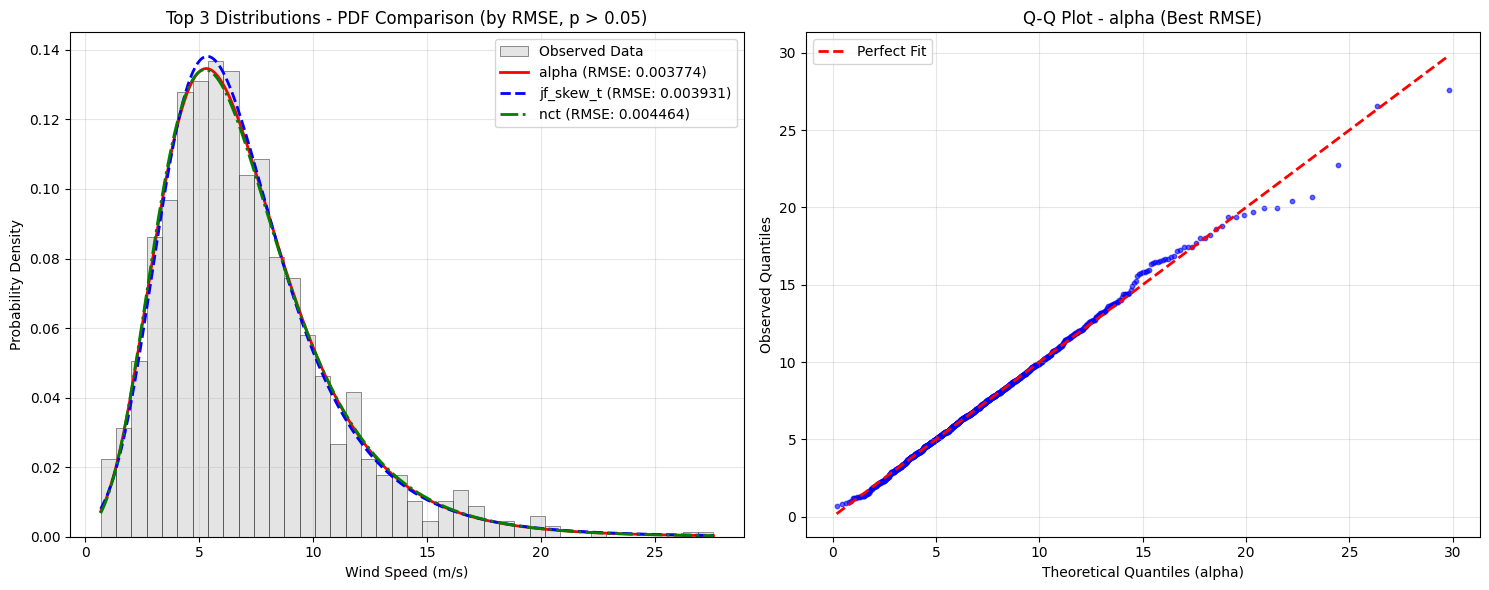


📊 Detailed Comparison of Top 3 Distributions (by RMSE, p > 0.05):
Distribution         RMSE         AIC      KS p-val   Parameters
alpha                0.003774     5224.7   0.9999     (3 params)
jf_skew_t            0.003931     5230.2   0.9990     (4 params)
nct                  0.004464     5225.8   0.9981     (4 params)

💡 Note: These distributions were selected by lowest RMSE and filtered by p > 0.05


In [11]:
# Get top 3 distributions from comprehensive analysis (filtered by p > 0.05)
top_3_dists = [dist for dist, _ in good_fit_comprehensive[:3]]
colors = ['red', 'blue', 'green']
linestyles = ['-', '--', '-.']

print(f"Visualizing top 3 distributions (by RMSE, p > 0.05): {top_3_dists}")

# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Histogram with fitted PDFs
ax1.hist(wind_data, bins=40, density=True, alpha=0.6, color='lightgray', 
         label='Observed Data', edgecolor='black', linewidth=0.5)

# Generate smooth curves for top distributions
x_smooth = np.linspace(wind_data.min(), wind_data.max(), 500)

for i, dist_name in enumerate(top_3_dists):
    # Get the fitted adjuster for this distribution
    result = dict(good_fit_comprehensive)[dist_name]
    
    # Create temporary processor and fit
    temp_processor = ma.read_data(wind_data)
    temp_processor.fit_distribution(dist_name)
    
    # Plot PDF
    pdf_smooth = temp_processor.pdf(x_smooth)
    ax1.plot(x_smooth, pdf_smooth, color=colors[i], linestyle=linestyles[i], 
            linewidth=2, label=f'{dist_name} (RMSE: {result["rmse"]:.6f})')

ax1.set_xlabel('Wind Speed (m/s)')
ax1.set_ylabel('Probability Density')
ax1.set_title('Top 3 Distributions - PDF Comparison (by RMSE, p > 0.05)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Q-Q plot for best distribution
best_dist_name = top_3_dists[0]
temp_processor = ma.read_data(wind_data)
temp_processor.fit_distribution(best_dist_name)

# Generate theoretical quantiles
sorted_data = np.sort(wind_data)
n = len(sorted_data)
theoretical_quantiles = temp_processor.ppf(np.arange(1, n+1) / (n+1))

ax2.scatter(theoretical_quantiles, sorted_data, alpha=0.6, s=10, color='blue')
# Add reference line
min_val = min(theoretical_quantiles.min(), sorted_data.min())
max_val = max(theoretical_quantiles.max(), sorted_data.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit')

ax2.set_xlabel(f'Theoretical Quantiles ({best_dist_name})')
ax2.set_ylabel('Observed Quantiles')
ax2.set_title(f'Q-Q Plot - {best_dist_name} (Best RMSE)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print goodness-of-fit metrics for top 3
print("\n📊 Detailed Comparison of Top 3 Distributions (by RMSE, p > 0.05):")
print("=" * 80)
print(f"{'Distribution':<20} {'RMSE':<12} {'AIC':<8} {'KS p-val':<10} {'Parameters'}")
print("=" * 80)

for dist_name in top_3_dists:
    result = dict(good_fit_comprehensive)[dist_name]
    params_str = f"({len(result['parameters'])} params)"
    print(f"{dist_name:<20} {result['rmse']:<12.6f} {result['aic']:<8.1f} {result['ks_pvalue']:<10.4f} {params_str}")

print("\n💡 Note: These distributions were selected by lowest RMSE and filtered by p > 0.05")

## Summary and Best Practices

### Key AutoFitter Features:

1. **Multiple Testing Strategies**:
   - **Default**: 16 curated, stable distributions (fast, reliable)
   - **Comprehensive**: All 113 SciPy distributions (thorough, slower)
   - **Custom**: Domain-specific distribution subsets

2. **Selection Criteria**:
   - `rmse`: Root Mean Square Error (good for overall fit)
   - `aic`/`bic`: Information criteria (balance fit vs complexity)
   - `ks_pvalue`/`chi2_pvalue`: Statistical test p-values

3. **Memory Efficiency**:
   - Lazy initialization - distributions fitted only when tested
   - Failed fits don't crash the process
   - Comprehensive error handling

### Recommended Workflow:

```python
# 1. Start with default (fast screening)
auto_fitter = processor.get_auto_fitter()
best_default = auto_fitter.fit_best_distribution()

# 2. If needed, do comprehensive search
all_dists = AutoFitter.get_all_available_distributions()
auto_fitter_all = processor.get_auto_fitter(candidates=all_dists)
best_comprehensive = auto_fitter_all.fit_best_distribution()

# 3. Use the best distribution
best_adjuster = auto_fitter.get_best_adjuster()
percentile_95 = best_adjuster.ppf(0.95)
```

### When to Use What:

- **Default AutoFitter**: Quick analysis, most real-world cases
- **Comprehensive AutoFitter**: Research, when you need the absolute best fit
- **Custom candidates**: Domain expertise, specific requirements
- **Different criteria**: AIC/BIC for model selection, p-values for statistical validity

**AutoFitter makes distribution selection effortless while giving you complete control when needed!** 🎯